# Why should you accumulate BTC?

The world we live in is becoming increasingly abstract; along with the tangible, physical world that all living creatures inhabit, there exists a digital world consisting of networks and systems with mind-boggling layers of connectivity to power our growing needs.

Today, the demands of that digital world have become large enough to demand its own economy; as global commerce becomes increasingly digital, we have outgrown the limitations of centralized financial systems and geography. A new question emerged: how can we support the scale and speed demands of modern commerce without breaking physical limitations or the social contract of trust?

Enter, cryptocurrency. We now have an elegant solution for a number of bottlenecks that traditional financial infrastructure can struggle with: trusted accounting, 24/7 settlement, transparent auditability, double spending. We can even program our own money now rather than relying on minted coins and notes, furthering the abstraction of money as a mode of transaction. This logic is particularly true for Bitcoin, which has earned a public reputation as "digital gold".

Bitcoin has become an investable asset for a simple reason: a growing number of people and institutions want exposure to a scarce, globally transferable digital asset. Its fixed issuance schedule and expanding network further support an investment thesis. However, that thesis comes with an important warning. Bitcoin has already experienced enormous drawdowns, and its future adoption and price remain uncertain. From a portfolio perspective, the question is therefore not only *why* own BTC, but also *how* to build a position without relying on a perfect entry point.

## Methodology

This study asks two questions.
1. How did Bitcoin perform compared to the S&P 500 over the same period using equal periodic dollar-cost averaging?
2. Does the choice of accumulation engine — DCA, value averaging, or buy-the-dip — change the outcome when each engine is applied to both assets?

The backtest runs the same dollar contribution targets on BTC-USD and SPY. It compares ending value, cash required, capital efficiency, and drawdown. BTC trades every day, while SPY contributes on its valid market-trading days. When a calendar purchase date is not a trading day for SPY, the purchase occurs on the first available observation on or after that date.

This is a historical experiment, not a forecast or personal investment advice. The baseline excludes fees, spreads, slippage, and taxes. Every strategy is long-only: it can buy the tested asset, but never sells it.

The analysis uses BTC-USD daily candles from Coinbase and adjusted SPY daily prices from Yahoo Finance between July 3, 2021 and July 2, 2026.

In [18]:
from datetime import date, timedelta
from pathlib import Path
import json
import time
from urllib.parse import urlencode
from urllib.request import Request, urlopen

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

START_DATE = date(2021, 7, 3)
END_DATE = date(2026, 7, 2)
REPO_ROOT = Path.cwd().parent if Path.cwd().name in {"drafts", "website"} else Path.cwd()
DATA_DIR = REPO_ROOT / "data/crypto"
FIGURE_DIR = REPO_ROOT / "figures/crypto"
BTC_PATH = DATA_DIR / "btc_usd_daily.csv"
SPY_PATH = DATA_DIR / "spy_daily_adjusted.csv"
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Study window: {START_DATE} through {END_DATE}")

Study window: 2021-07-03 through 2026-07-02


In [19]:
# Downloads Coinbase daily candles in small public-API windows.
def fetch_coinbase_daily_candles(start_date, end_date):
    rows = []
    window_start = start_date
    while window_start <= end_date:
        window_end = min(window_start + timedelta(days=299), end_date)
        query = urlencode({"granularity":86400, "start":f"{window_start}T00:00:00Z", "end":f"{window_end + timedelta(days=1)}T00:00:00Z"})
        request = Request(f"https://api.exchange.coinbase.com/products/BTC-USD/candles?{query}", headers={"User-Agent":"data-articles-btc-study/1.0"})
        with urlopen(request, timeout=30) as response:
            rows.extend(json.loads(response.read().decode("utf-8")))
        window_start = window_end + timedelta(days=1)
        time.sleep(0.2)
    candles = pd.DataFrame(rows, columns=["timestamp","low","high","open","close","volume"])
    candles["date"] = pd.to_datetime(candles["timestamp"], unit="s", utc=True).dt.tz_localize(None).dt.normalize()
    return candles[["date","open","high","low","close","volume"]].drop_duplicates("date").sort_values("date").reset_index(drop=True)

# Loads the BTC cache or creates it from Coinbase.
def load_btc_data(path):
    if path.exists():
        data = pd.read_csv(path, parse_dates=["date"])
        print(f"Loaded cached BTC data: {path}")
    else:
        print("No BTC cache found; downloading Coinbase candles...")
        data = fetch_coinbase_daily_candles(START_DATE, END_DATE)
        data.to_csv(path, index=False)
    data["date"] = pd.to_datetime(data["date"]).dt.normalize()
    data["close"] = pd.to_numeric(data["close"], errors="coerce")
    return data[data["date"].between(pd.Timestamp(START_DATE), pd.Timestamp(END_DATE))].dropna(subset=["close"]).sort_values("date").drop_duplicates("date").reset_index(drop=True)

# Downloads and caches adjusted SPY prices from Yahoo Finance.
def load_spy_data(path):
    if path.exists():
        data = pd.read_csv(path, parse_dates=["date"])
        print(f"Loaded cached SPY data: {path}")
    else:
        print("No SPY cache found; downloading adjusted Yahoo Finance prices...")
        downloaded = yf.download("SPY", start=str(START_DATE), end=str(END_DATE + timedelta(days=1)), auto_adjust=True, progress=False)
        if downloaded.empty:
            raise RuntimeError("Yahoo Finance returned no SPY data.")
        close = downloaded["Close"]
        if isinstance(close, pd.DataFrame):
            close = close.iloc[:, 0]
        data = close.rename("close").rename_axis("date").reset_index()
        data["date"] = pd.to_datetime(data["date"]).dt.tz_localize(None).dt.normalize()
        data.to_csv(path, index=False)
    data["date"] = pd.to_datetime(data["date"]).dt.normalize()
    data["close"] = pd.to_numeric(data["close"], errors="coerce")
    return data[data["date"].between(pd.Timestamp(START_DATE), pd.Timestamp(END_DATE))].dropna(subset=["close"]).sort_values("date").drop_duplicates("date").reset_index(drop=True)

asset_data = {"BTC": load_btc_data(BTC_PATH), "SPY": load_spy_data(SPY_PATH)}
for asset, data in asset_data.items():
    print(f"{asset}: {len(data):,} rows, {data['date'].min().date()} through {data['date'].max().date()}, duplicates={data['date'].duplicated().sum()}")
    assert data["date"].duplicated().sum() == 0
    assert data["close"].notna().all()

Loaded cached BTC data: /Users/vijayneelakantan/remote-repos-on-local/data-articles/data/crypto/btc_usd_daily.csv
Loaded cached SPY data: /Users/vijayneelakantan/remote-repos-on-local/data-articles/data/crypto/spy_daily_adjusted.csv
BTC: 1,826 rows, 2021-07-03 through 2026-07-02, duplicates=0
SPY: 1,254 rows, 2021-07-06 through 2026-07-02, duplicates=0


Now that the data is loaded, let's define the accumulation engines for each portfolio prior to the backtest.

## Accumulation Engines

- **Dollar-cost averaging (DCA):** buy the same dollar amount on a regular schedule.
- **Value averaging:** set a target path for the portfolio and buy more when the portfolio falls behind that path; buy less or nothing when it is ahead.
- **Buy-the-dip:** keep the dollar amount fixed, but buy only after the asset falls by a chosen percentage over a chosen period.

### Configurations

- **DCA**: buy \$100 at month-end, regardless of the price. This means partial buys for BTC and SPY are enabled.
- **Value averaging**: a target path that grows by \$100 every month-end.
- **Buy-the-dip**: buy \$100 at month-end after a 10% one-month decline.

The same dollar targets are applied to both BTC and SPY. For SPY, purchases execute on the first available trading day on or after the calendar target.


In [20]:
# Maps calendar targets to the first valid observation for an asset.
def execution_dates(asset_dates, cadence):
    dates = pd.Series(pd.to_datetime(asset_dates).drop_duplicates().sort_values())
    if cadence == "daily":
        targets = pd.date_range(dates.iloc[0], dates.iloc[-1], freq="D")
    elif cadence == "weekly":
        targets = pd.date_range(dates.iloc[0], dates.iloc[-1], freq="7D")
    else:
        targets = pd.date_range(dates.iloc[0] + pd.offsets.MonthEnd(0), dates.iloc[-1], freq="ME")
    return pd.Index(dates.iloc[np.searchsorted(dates.values, targets.values, side="left")].drop_duplicates())

# Builds a fixed-dollar DCA schedule using calendar targets.
def dca_purchases(data, amount, cadence):
    return {pd.Timestamp(day): float(amount) for day in execution_dates(data["date"], cadence)}

# Builds purchases that keep the portfolio on a planned value path.
def value_average_purchases(data, amount, cadence):
    dates = execution_dates(data["date"], cadence)
    prices = data.set_index("date")["close"]
    purchases, held, target = {}, 0.0, 0.0
    for day in dates:
        target += amount
        price = prices.loc[day]
        purchase = max(0.0, target - held * price)
        if purchase > 0:
            purchases[day] = purchase
            held += purchase / price
    return purchases

# Buys at month-end only when the asset has fallen by a specified trailing amount.
def dip_purchases(data, amount, lookback, threshold, cadence="monthly"):
    prices = data.set_index("date")["close"]
    signal_dates = execution_dates(data["date"], cadence)
    trailing_returns = prices / prices.shift(lookback) - 1
    signal_dates = [day for day in signal_dates if trailing_returns.get(day, np.nan) <= threshold]
    return {pd.Timestamp(day): float(amount) for day in signal_dates}

# Creates a complete portfolio history from an asset and purchase ledger.
def build_portfolio(data, purchases, asset, engine):
    history = data[["date","close"]].copy()
    history["purchase"] = history["date"].map(purchases).fillna(0.0)
    history["units_bought"] = history["purchase"] / history["close"]
    history["cash_contributed"] = history["purchase"].cumsum()
    history["units_held"] = history["units_bought"].cumsum()
    history["portfolio_value"] = history["units_held"] * history["close"]
    history["running_peak"] = history["portfolio_value"].cummax()
    history["drawdown"] = history["portfolio_value"] / history["running_peak"] - 1
    history["asset"], history["engine"] = asset, engine
    return history

engine_specs = {
    "DCA $100 month-end": ("dca", 100, "monthly"),
    "Value avg $100 month-end": ("value", 100, "monthly"),
    "Buy dip $100 after -10% month": ("dip", 100, "monthly"),
}

portfolios = {}
for asset, data in asset_data.items():
    for engine, (kind, amount, cadence) in engine_specs.items():
        if kind == "dca": purchases = dca_purchases(data, amount, cadence)
        elif kind == "value": purchases = value_average_purchases(data, amount, cadence)
        else:
            lookback = {"BTC":30, "SPY":21}[asset]
            purchases = dip_purchases(data, amount, lookback, -0.10, cadence)
        portfolios[(asset, engine)] = build_portfolio(data, purchases, asset, engine)

print(f"Built {len(portfolios)} asset-engine histories.")

Built 6 asset-engine histories.


Now, let's perform the backtest via calculating money-weighted annual return. This metric measures an investor's actual annualized experience while accounting for where and how much money each accumulation strategy contributed.

For results, the same metrics are used for every asset-engine pair so that a higher ending value is not confused with better capital efficiency.

In [21]:
# Calculates money-weighted annual return from dated cash flows.
def calculate_irr(history):
    invested = history[history["purchase"] > 0]
    if invested.empty: return np.nan
    flows = [-x for x in invested["purchase"]] + [float(history.iloc[-1]["portfolio_value"])]
    dates = list(invested["date"]) + [history.iloc[-1]["date"]]
    years = np.array([(day - dates[0]).days / 365.25 for day in dates])
    def npv(rate): return sum(flow / (1 + rate) ** year for flow, year in zip(flows, years))
    low, high = -0.9999, 100.0
    if npv(low) * npv(high) > 0: return np.nan
    for _ in range(150):
        mid = (low + high) / 2
        if npv(low) * npv(mid) <= 0: high = mid
        else: low = mid
    return (low + high) / 2

# Summarizes every asset-engine combination on the same metrics.
def summarize(history):
    invested = history["purchase"].sum()
    ending = history.iloc[-1]["portfolio_value"]
    return {"Asset":history.iloc[0]["asset"], "Engine":history.iloc[0]["engine"], "Buys":int((history["purchase"] > 0).sum()), "Total Invested":invested, "Ending Value":ending, "Profit":ending-invested, "Return on Cash":ending/invested-1 if invested else np.nan, "IRR":calculate_irr(history), "Max Drawdown":history["drawdown"].min(), "Days Below Cash":(history["portfolio_value"] < history["cash_contributed"]).mean()}

results = pd.DataFrame([summarize(history) for history in portfolios.values()])
display(results.sort_values(["Engine","Asset"]).reset_index(drop=True).style.format({"Total Invested":"${:,.0f}","Ending Value":"${:,.0f}","Profit":"${:,.0f}","Return on Cash":"{:.1%}","IRR":"{:.1%}","Max Drawdown":"{:.1%}","Days Below Cash":"{:.1%}"}))

,Asset,Engine,Buys,Total Invested,Ending Value,Profit,Return on Cash,IRR,Max Drawdown,Days Below Cash
0,BTC,Buy dip $100 after -10% month,14,"$1,400","$2,377",$977,69.8%,20.5%,-46.7%,24.4%
1,SPY,Buy dip $100 after -10% month,0,$0,$0,$0,nan%,nan%,nan%,0.0%
2,BTC,DCA $100 month-end,60,"$6,000","$8,737","$2,737",45.6%,15.5%,-48.8%,33.0%
3,SPY,DCA $100 month-end,60,"$6,000","$9,327","$3,327",55.4%,18.2%,-15.9%,25.0%
4,BTC,Value avg $100 month-end,16,"$2,776","$6,695","$3,919",141.2%,23.8%,-53.1%,24.4%
5,SPY,Value avg $100 month-end,30,"$3,795","$6,545","$2,749",72.4%,18.5%,-12.2%,22.3%


## Results

The fairest comparison is the shared \$100 month-end DCA baseline: over this study window, SPY finished with the higher portfolio value and a much smaller drawdown than BTC. The DCA rows answer the direct BTC-versus-SPY accumulation question.

The value averaging results look more interesting: BTC looked more attractive because it produced a higher return on the cash actually invested, but it also deployed a different amount of capital and experienced a deeper drawdown.

The most direct conclusion is that SPY was the more consistent accumulation asset in this sample, while BTC offered greater upside potential only through a more volatile and capital-sensitive path.

## Conclusion

This experiment answers two questions that are often mixed together: whether BTC outperformed SPY as an accumulation asset, and whether a particular accumulation engine improved the outcome. Equal periodic DCA provides the clean baseline, whereas value averaging and buy-the-dip portfolios showcase how adaptive rules change cash deployment, ending value, and drawdown.

Over the backtest's five-year span, SPY was the stronger and more consistent accumulation asset under the fairest comparison: investing the same $100 at month-end produced a higher ending value, higher money-weighted return, and much smaller drawdown than BTC. However, BTC became more attractive under value averaging, which produced a higher return on contributed cash, even though that came with deeper drawdowns and different capital deployment.

To answer the original question: accumulate BTC if you believe bigger risk begets bigger rewards in the financial markets.



## Limitations

- BTC trades continuously while SPY trades only on exchange days; the notebook uses each asset's first valid observation on or after a calendar target.
- SPY uses adjusted Yahoo Finance prices; BTC uses Coinbase closes. These are comparable daily proxies, not identical execution venues.
- Fees, spreads, slippage, and taxes are excluded.
- The study covers one historical window and does not establish future performance.
- Value averaging has no maximum purchase cap in this baseline.
- The SPY buy-the-dip rule did not trigger during this sample, so its zero-investment result is not a meaningful performance comparison.
- Value averaging does not contribute the same total cash as DCA; its return-on-cash comparison reflects that different capital deployment.
- The study is educational and not personalized financial advice.

## Appendix

Plot of equity curves:

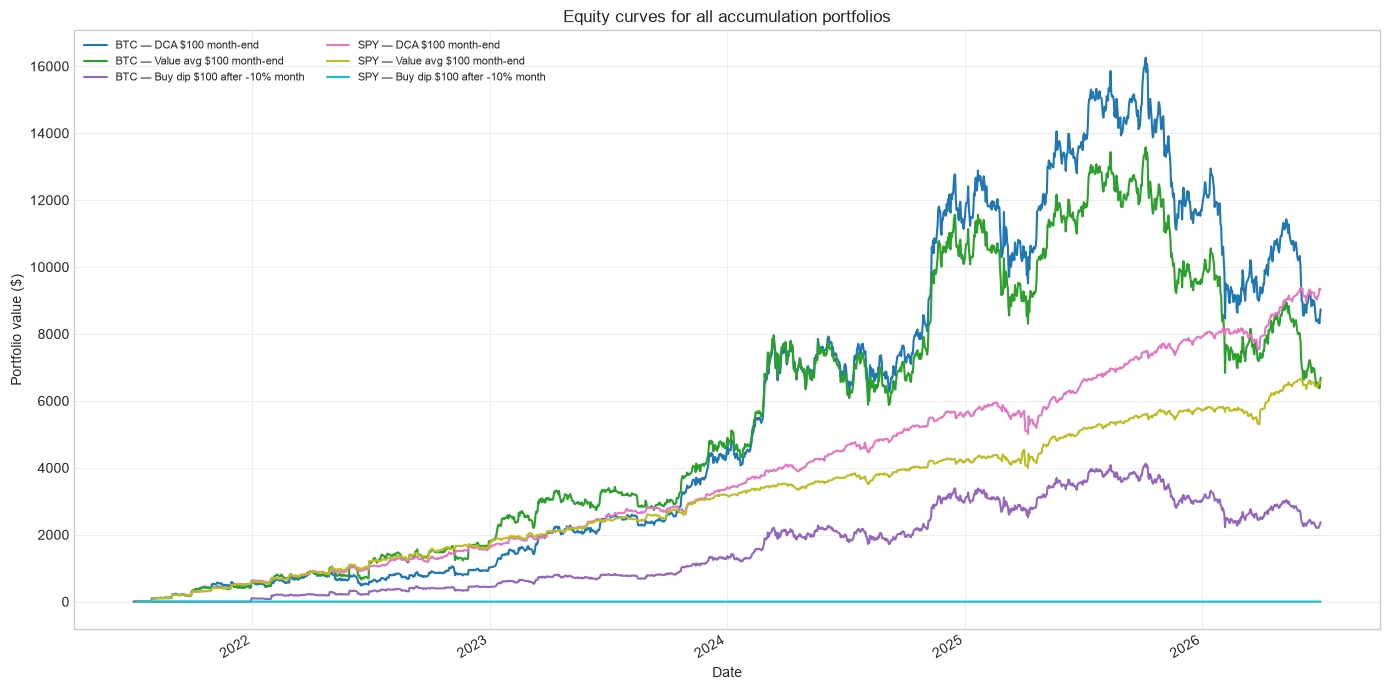

In [17]:
plt.style.use("seaborn-v0_8-whitegrid")

# Shows the equity curve for every asset-engine portfolio in one chart.
fig, ax = plt.subplots(figsize=(14, 7))
colors = plt.cm.tab10(np.linspace(0, 1, len(portfolios)))
for color, ((asset, engine), history) in zip(colors, portfolios.items()):
    ax.plot(history["date"], history["portfolio_value"], color=color, linewidth=1.5, label=f"{asset} — {engine}")
ax.set_title("Equity curves for all accumulation portfolios")
ax.set_xlabel("Date")
ax.set_ylabel("Portfolio value ($)")
ax.legend(loc="upper left", fontsize=8, ncol=2)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "all-portfolio-equity-curves.png", dpi=160)
plt.show()